In [ ]:
!pip install -U transformers datasets accelerate evaluate scikit-learn pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 10.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: pandas
   

Map:   0%|          | 0/35000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7500 [00:00<?, ? examples/s]

Map:   0%|          | 0/7500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.577168,0.738000,0.718280,0.762557,0.678862


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

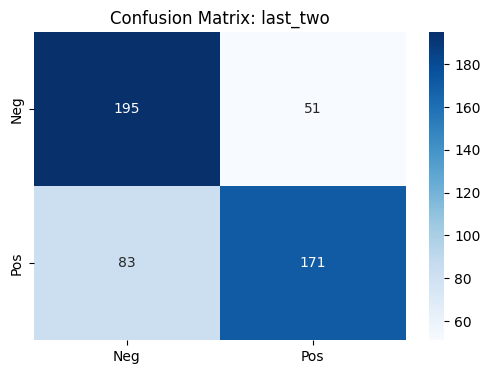

              precision    recall  f1-score   support

           0       0.70      0.79      0.74       246
           1       0.77      0.67      0.72       254

    accuracy                           0.73       500
   macro avg       0.74      0.73      0.73       500
weighted avg       0.74      0.73      0.73       500



In [ ]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

# Set seed for reproducibility
set_seed(42)

# --- STEP 1: DATA PREPROCESSING ---
# Path for Kaggle/Colab environment
path = '/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'
df = pd.read_csv(path)

# Mandatory Cleaning
df = df.dropna()
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# --- STEP 2: DATA SPLITTING ---
# 70% Train, 15% Val, 15% Test
train_df, rem_df = train_test_split(df, train_size=0.7, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(rem_df, test_size=0.5, stratify=rem_df['label'], random_state=42)

ds = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df)
})

# --- STEP 3: TOKENIZATION ---
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["review"], truncation=True, padding="max_length", max_length=256)

tokenized_datasets = ds.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["review", "sentiment", "__index_level_0__"])
tokenized_datasets.set_format("torch")

# --- STEP 4: EXPERIMENT LOGIC ---
def get_model(experiment="full"):
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

    if experiment == "frozen":
        for param in model.bert.parameters():
            param.requires_grad = False
    elif experiment == "last_two":
        for param in model.bert.parameters():
            param.requires_grad = False
        for layer in model.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True
    return model

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# --- STEP 5: TRAINING ---
# Change this to "frozen" or "full" for your other experiments
current_exp = "last_two"
model = get_model(current_exp)

training_args = TrainingArguments(
    output_dir=f"./results_{current_exp}",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=1,            # Set to 2 or 3 for final run
    weight_decay=0.01,
    eval_strategy="epoch",         # Updated from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"].shuffle(seed=42).select(range(2000)), # Subset for speed
    eval_dataset=tokenized_datasets["validation"].select(range(500)),
    processing_class=tokenizer,    # Updated from tokenizer=tokenizer
    compute_metrics=compute_metrics,
)

trainer.train()

# --- STEP 6: EVALUATION ---
results = trainer.predict(tokenized_datasets["test"].select(range(500)))
y_preds = np.argmax(results.predictions, axis=-1)
y_true = results.label_ids

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title(f'Confusion Matrix: {current_exp}')
plt.show()

print(classification_report(y_true, y_preds))